In [ ]:
# Prompt Chaining Architecture -> 작업을 고정된 하위 작업으로 깔끔하게 분해할 수 있을 때 이상적
# 프로세스의 결과가 다음 프로세스에서 처리(사용)된다

# Routing Architecture -> 입력을 명확하게 분류 할 수 있을때 좋음. 명확하게 분류할 수 없는 입력일 때는 쓰지 않는게...
# 분류기(라우터)는 저렴한 모델로 각각의 프롬프트는 비교적 비싼 모델로 처리함으로써 비용 절약 가능


from operator import add
from typing import Annotated

from langchain.chat_models import init_chat_model
from langgraph.graph import END, START, StateGraph
from langgraph.types import Send
from typing_extensions import TypedDict

llm = init_chat_model("openai:gpt-4o-mini")

In [61]:
class State(TypedDict):
    document: str
    final_summary: str
    summaries: Annotated[list[str], add]

In [ ]:
def summarize_p(args):
    paragraph = args["paragraph"]
    index = args["index"]
    response = llm.invoke(f"Write a 3-sentence summary for this paragraph: {paragraph}")
    return {
        "summaries": [
            {
                "summary": response.content,
                "index": index,
            }
        ]
    }


def dispatch_summarizers(state: State):
    chunks = state["document"].split("\n\n")
    return [
        Send("summarize_p", {"paragraph": chunk, "index": index})
        for index, chunk in enumerate(chunks)
    ]


def final_summary(state: State):
    response = llm.invoke(
        f"Using the following summaries, give me a final one {state['summaries']}"
    )
    return {
        "final_summary": response.content,
    }

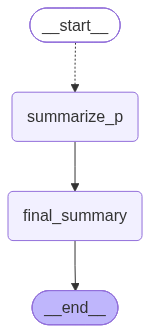

In [65]:
graph_builder = StateGraph(State)

graph_builder.add_node("summarize_p", summarize_p)
graph_builder.add_node("final_summary", final_summary)


graph_builder.add_conditional_edges(
    START,
    dispatch_summarizers,
    ["summarize_p"],
)

graph_builder.add_edge("summarize_p", "final_summary")
graph_builder.add_edge("final_summary", END)


graph = graph_builder.compile()
graph

In [ ]:
with open("fed_transcript.md", "r", encoding="utf-8") as file:
    document = file.read()


for chunk in graph.stream(
    {"document": document},
    stream_mode="updates",
):
    print(chunk, "\n")